# 🧮 Solving Linear Systems — Elimination, Classification, and Conditioning

**Linear Algebra and Analytic Geometry** · TSIW, ESMAD — Polytechnic of Porto
Lesson notebook **03 of 08** · Library: [`linalg_utils`](../packages/python/src/linalg_utils)

> **Assignment alignment** — supports assignment **A4** (linear systems: Gaussian
> elimination and classification).

---

The central computational problem of linear algebra:

$$A\mathbf{x} = \mathbf{b} \qquad \text{— given the map } A \text{ and the output }
\mathbf{b}\text{, recover the input } \mathbf{x}.$$

We attack it from three angles:

- **Geometry** — a 2×2 system is two lines; the solution is where they cross (or don't).
- **Algorithm** — Gaussian elimination reduces the system to a triangle we can unwind, and
  classifies it as *SPD / SPI / SI* (unique / infinite / no solutions).
- **Numerics** — even a solvable system can be treacherous: **conditioning** measures how
  violently the answer reacts to tiny input errors.

## Table of contents

1. [Setup](#setup)
2. [The row picture and the column picture](#pictures)
3. [Gaussian elimination, step by step](#gauss)
4. [Classifying systems: SPD, SPI, SI](#classify)
5. [Solving and checking residuals](#solve)
6. [Conditioning: when good systems go bad](#conditioning)
7. [Sensitivity experiment](#sensitivity)
8. [Key takeaways](#takeaways)

<a id="setup"></a>
## 1 · Setup

In [1]:
# ── Setup: imports, course library, and a consistent figure style ──────────
import sys
from pathlib import Path

# Make the course library importable straight from a repo clone
# (equivalent to `poetry install` inside packages/python).
_SRC = (Path.cwd().parent / "packages" / "python" / "src").resolve()
if _SRC.exists() and str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

import numpy as np
import matplotlib.pyplot as plt

# Colorblind-safe categorical palette, used in fixed order across the series.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, MUTED, GRID, BASE = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor":   "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor":   BASE,
    "axes.labelcolor":  INK,
    "axes.titlecolor":  INK,
    "axes.titleweight": "bold",
    "axes.grid":        True,
    "grid.color":       GRID,
    "grid.linewidth":   0.8,
    "xtick.color":      MUTED,
    "ytick.color":      MUTED,
    "axes.prop_cycle":  plt.cycler(color=PALETTE),
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "legend.frameon":   False,
    "figure.dpi":       110,
})
np.set_printoptions(precision=4, suppress=True)

import linalg_utils
print("NumPy", np.__version__, "| linalg_utils loaded from", Path(linalg_utils.__file__).parent)

NumPy 2.3.5 | linalg_utils loaded from C:\Users\diogo\work_code\linear-algebra-with-python\packages\python\src\linalg_utils


<a id="pictures"></a>
## 2 · The row picture and the column picture

Take the running example

$$\begin{cases} 3x_1 + x_2 = 9 \\ x_1 + 2x_2 = 7 \end{cases}
\;\Longleftrightarrow\;
\underbrace{\begin{pmatrix} 3 & 1 \\ 1 & 2 \end{pmatrix}}_{A}
\begin{pmatrix} x_1 \\ x_2 \end{pmatrix}
= \underbrace{\begin{pmatrix} 9 \\ 7 \end{pmatrix}}_{\mathbf{b}}.$$

The same system has **two pictures**:

- **Row picture** — each equation is a line; the solution is their intersection.
- **Column picture** — $\mathbf{b}$ is a *combination of the columns* of $A$:
  find weights $x_1, x_2$ with $x_1\binom{3}{1} + x_2\binom{1}{2} = \binom{9}{7}$.

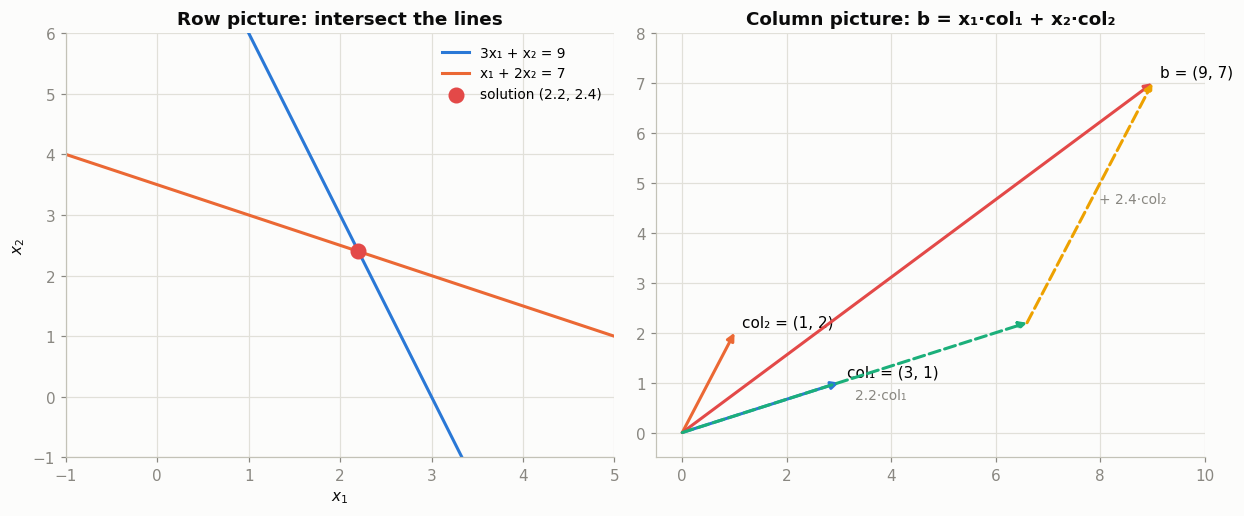

Both pictures agree: x = [2.2 2.4]


In [2]:
A = np.array([[3.0, 1.0], [1.0, 2.0]])
b = np.array([9.0, 7.0])
x_star = np.linalg.solve(A, b)          # (we'll re-derive this by elimination below)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))

# Row picture: two lines crossing at the solution.
ax = axes[0]
xs = np.linspace(-1, 5, 100)
ax.plot(xs, 9 - 3 * xs, color=PALETTE[0], lw=2, label="3x₁ + x₂ = 9")
ax.plot(xs, (7 - xs) / 2, color=PALETTE[1], lw=2, label="x₁ + 2x₂ = 7")
ax.scatter(*x_star, s=90, color=PALETTE[7], zorder=3,
           label=f"solution ({x_star[0]:.1f}, {x_star[1]:.1f})")
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 6)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Row picture: intersect the lines")
ax.legend(fontsize=9)

# Column picture: b as a combination of the columns.
ax = axes[1]
c1, c2 = A[:, 0], A[:, 1]
for vec, colr, lab in [(c1, PALETTE[0], "col₁ = (3, 1)"),
                       (c2, PALETTE[1], "col₂ = (1, 2)"),
                       (b, PALETTE[7], "b = (9, 7)")]:
    ax.annotate("", xy=tuple(vec), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=colr, lw=2, shrinkA=0, shrinkB=0))
    ax.annotate(lab, xy=tuple(vec), xytext=(5, 4), textcoords="offset points", fontsize=10)
# walk the combination: x₁·col₁ then + x₂·col₂
step1 = x_star[0] * c1
ax.annotate("", xy=tuple(step1), xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", color=PALETTE[2], lw=2, ls="--", shrinkA=0, shrinkB=0))
ax.annotate("", xy=tuple(step1 + x_star[1] * c2), xytext=tuple(step1),
            arrowprops=dict(arrowstyle="-|>", color=PALETTE[3], lw=2, ls="--", shrinkA=0, shrinkB=0))
ax.annotate(f"{x_star[0]:.1f}·col₁", xy=tuple(step1 / 2), xytext=(0, -14),
            textcoords="offset points", color=MUTED, fontsize=9)
ax.annotate(f"+ {x_star[1]:.1f}·col₂", xy=tuple(step1 + x_star[1] * c2 / 2),
            xytext=(6, 0), textcoords="offset points", color=MUTED, fontsize=9)
ax.set_xlim(-0.5, 10)
ax.set_ylim(-0.5, 8)
ax.set_title("Column picture: b = x₁·col₁ + x₂·col₂")
plt.tight_layout()
plt.show()

print(f"Both pictures agree: x = {x_star}")

<a id="gauss"></a>
## 3 · Gaussian elimination, step by step

Elimination transforms the **augmented matrix** $[A \mid \mathbf{b}]$ into an upper-triangular
(echelon) form using row operations, then **back-substitution** unwinds the triangle from the
bottom up.

The library's `escalonar` performs the elimination *and narrates every row operation it
makes* — exactly the trace you are asked to produce by hand in assignment A4.

In [3]:
from linalg_utils.systems import escalonar, substituicao_retroativa

aug = np.column_stack([A, b])
print("Augmented matrix [A | b]:")
print(aug, end="\n\n")

echelon, steps = escalonar(aug)
print("Row operations performed:")
for s in steps:
    print("  •", s)
print("\nEchelon form:")
print(echelon, end="\n\n")

x_gauss = substituicao_retroativa(echelon[:, :-1], echelon[:, -1])
print(f"Back-substitution → x = {x_gauss}")

Augmented matrix [A | b]:
[[3. 1. 9.]
 [1. 2. 7.]]

Row operations performed:
  • R2 <- R2 - (0.333333)*R1

Echelon form:
[[3.     1.     9.    ]
 [0.     1.6667 4.    ]]

Back-substitution → x = [2.2 2.4]


In [4]:
# The same machinery scales to 3×3 (or any size). One call does it all:
from linalg_utils.systems import resolver_gauss

A3 = np.array([[2.0, -1.0, 0.0],
               [0.0,  3.0, 1.0],
               [1.0,  2.0, 4.0]])
b3 = np.array([2.0, 5.0, 9.0])

x3, classification, steps3 = resolver_gauss(A3, b3)
print(f"classification: {classification}  (SPD = unique solution)")
print(f"x = {x3}\n")
print("elimination trace:")
for s in steps3:
    print("  •", s)

classification: SPD  (SPD = unique solution)
x = [1.6316 1.2632 1.2105]

elimination trace:
  • R3 <- R3 - (0.5)*R1
  • R3 <- R3 - (0.833333)*R2


<a id="classify"></a>
## 4 · Classifying systems: SPD, SPI, SI

Not every system has exactly one solution. Comparing $\operatorname{rank}(A)$ with
$\operatorname{rank}([A \mid \mathbf{b}])$ and the number of unknowns $n$ gives the
**Rouché–Capelli classification** used throughout the Portuguese literature:

| code | name | condition | geometry (2×2) |
|---|---|---|---|
| **SPD** | *sistema possível e determinado* | $\text{rank}(A) = \text{rank}([A|b]) = n$ | lines cross once |
| **SPI** | *sistema possível e indeterminado* | $\text{rank}(A) = \text{rank}([A|b]) < n$ | same line twice |
| **SI**  | *sistema impossível* | $\text{rank}(A) < \text{rank}([A|b])$ | parallel lines |

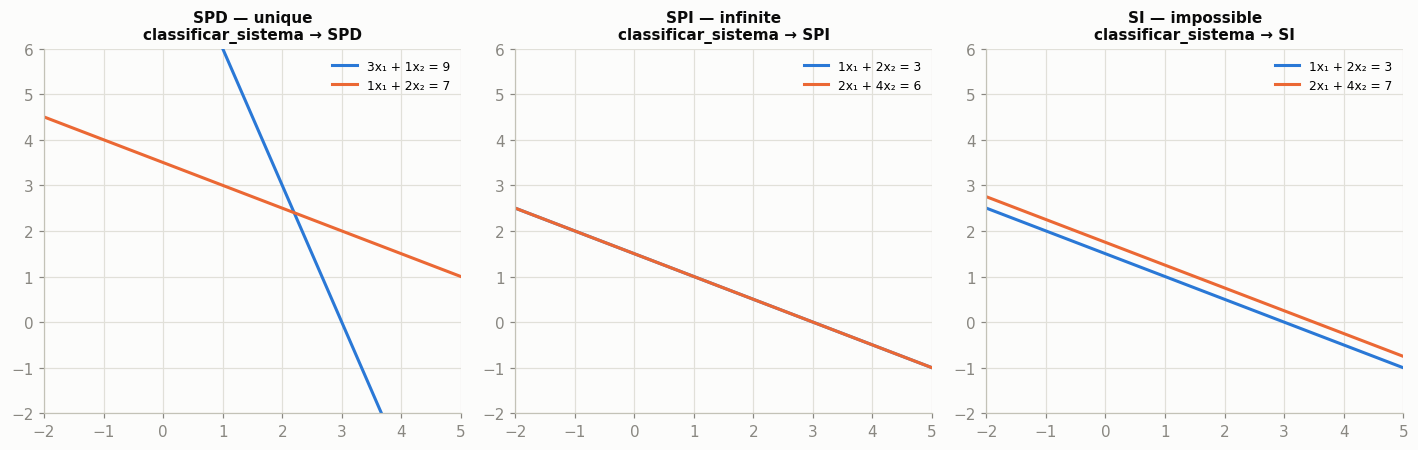

In [5]:
from linalg_utils.systems import classificar_sistema

cases = {
    "SPD — unique":     (np.array([[3.0, 1.0], [1.0, 2.0]]), np.array([9.0, 7.0])),
    "SPI — infinite":   (np.array([[1.0, 2.0], [2.0, 4.0]]), np.array([3.0, 6.0])),
    "SI — impossible":  (np.array([[1.0, 2.0], [2.0, 4.0]]), np.array([3.0, 7.0])),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
xs = np.linspace(-2, 5, 100)
for ax, (title, (M, rhs)) in zip(axes, cases.items()):
    verdict = classificar_sistema(M, rhs)
    for i, colr in [(0, PALETTE[0]), (1, PALETTE[1])]:
        a1, a2 = M[i]
        c = rhs[i]
        if abs(a2) > 1e-12:
            ax.plot(xs, (c - a1 * xs) / a2, color=colr, lw=2,
                    label=f"{a1:g}x₁ + {a2:g}x₂ = {c:g}")
        else:
            ax.axvline(c / a1, color=colr, lw=2)
    ax.set_xlim(-2, 5)
    ax.set_ylim(-2, 6)
    ax.set_title(f"{title}\nclassificar_sistema → {verdict}", fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

<a id="solve"></a>
## 5 · Solving and checking residuals

For production use the library wraps NumPy's solver as `solve`, returning the solution
*together with its residual* $\mathbf{r} = A\mathbf{x} - \mathbf{b}$.

**Always check the residual.** A residual norm near machine precision
($\sim 10^{-15}$) certifies that the computed $\mathbf{x}$ satisfies the equations to within
floating-point accuracy.

In [6]:
from linalg_utils.systems import solve
from linalg_utils.checks import assert_close

for name, (M, rhs) in [("2×2", (A, b)), ("3×3", (A3, b3))]:
    res = solve(M, rhs)
    print(f"{name}: x = {res.x}   ‖Ax − b‖ = {res.residual_norm:.3e}")

# assert_close raises if the residual is *not* essentially zero — a built-in unit test.
res = solve(A, b)
assert_close("system residual", res.residual, np.zeros_like(res.residual), tol=1e-12)
print("\nassert_close passed: the residual is zero to 1e-12. ✔")

2×2: x = [2.2 2.4]   ‖Ax − b‖ = 0.000e+00
3×3: x = [1.6316 1.2632 1.2105]   ‖Ax − b‖ = 0.000e+00

assert_close passed: the residual is zero to 1e-12. ✔


<a id="conditioning"></a>
## 6 · Conditioning: when good systems go bad

A system can be *solvable* yet *numerically fragile*. The **condition number**

$$\kappa(A) = \lVert A\rVert \, \lVert A^{-1}\rVert \;\ge\; 1$$

bounds the damage: a relative error $\varepsilon$ in the data can become a relative error of
up to $\kappa(A)\,\varepsilon$ in the solution. Rule of thumb: **you lose about
$\log_{10}\kappa$ decimal digits of accuracy.**

Geometrically, an ill-conditioned 2×2 system is two **almost-parallel lines**: the
intersection point skates far away under the slightest nudge of either line.

 well-conditioned: κ(A) = 1.939e+00 → ≈ 0.3 digits at risk
  ill-conditioned: κ(A) = 4.000e+08 → ≈ 8.6 digits at risk


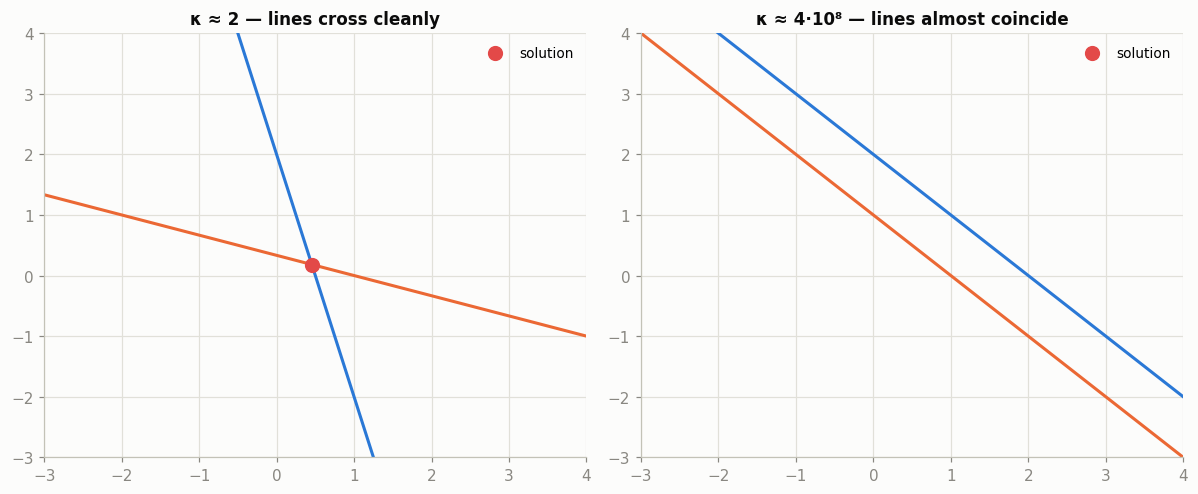

In [7]:
well = np.array([[4.0, 1.0], [1.0, 3.0]])              # κ ≈ 2
bad  = np.array([[1.0, 1.0], [1.0, 1.0 + 1e-8]])       # κ ≈ 4·10⁸ — nearly singular

for label, M in [("well-conditioned", well), ("ill-conditioned", bad)]:
    print(f"{label:>17s}: κ(A) = {np.linalg.cond(M):.3e} → "
          f"≈ {np.log10(np.linalg.cond(M)):.1f} digits at risk")

rhs = np.array([2.0, 1.0])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
xs = np.linspace(-3, 4, 100)
for ax, M, title in [(axes[0], well, "κ ≈ 2 — lines cross cleanly"),
                     (axes[1], bad,  "κ ≈ 4·10⁸ — lines almost coincide")]:
    for i, colr in [(0, PALETTE[0]), (1, PALETTE[1])]:
        a1, a2 = M[i]
        ax.plot(xs, (rhs[i] - a1 * xs) / a2, color=colr, lw=2)
    sol = np.linalg.solve(M, rhs)
    ax.scatter(*sol, s=80, color=PALETTE[7], zorder=3, label="solution")
    ax.set_xlim(-3, 4)
    ax.set_ylim(-3, 4)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

<a id="sensitivity"></a>
## 7 · Sensitivity experiment

We perturb the right-hand side by $\pm\varepsilon$ over ten orders of magnitude and measure
how far the solution moves, for both matrices. On a log–log plot the response is a straight
line whose *height* is set by $\kappa(A)$ — the ill-conditioned system amplifies every
perturbation by about $10^8$.

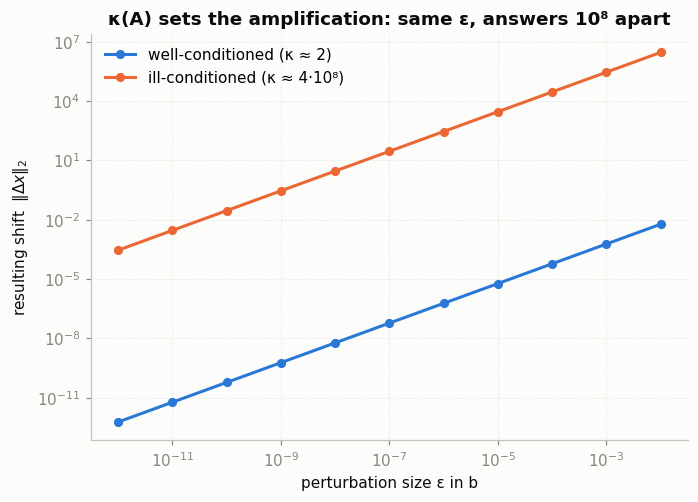

measured amplification at ε = 1e-6:  well ≈ 0.6×,  bad ≈ 2.828e+08×


In [8]:
base = np.array([2.0, 1.0])
eps_grid = np.geomspace(1e-12, 1e-2, 11)

fig, ax = plt.subplots(figsize=(7, 4.8))
for M, colr, label in [(well, PALETTE[0], "well-conditioned (κ ≈ 2)"),
                       (bad,  PALETTE[1], "ill-conditioned (κ ≈ 4·10⁸)")]:
    x0 = np.linalg.solve(M, base)
    shifts = [np.linalg.norm(np.linalg.solve(M, base + np.array([e, -e])) - x0)
              for e in eps_grid]
    ax.loglog(eps_grid, shifts, marker="o", ms=5, lw=2, color=colr, label=label)

ax.set_xlabel("perturbation size ε in b")
ax.set_ylabel(r"resulting shift  $\|\Delta x\|_2$")
ax.set_title("κ(A) sets the amplification: same ε, answers 10⁸ apart")
ax.grid(True, which="both", ls=":", lw=0.6)
ax.legend()
plt.show()

amp_well = np.linalg.norm(np.linalg.solve(well, base + np.array([1e-6, -1e-6])) - np.linalg.solve(well, base)) / 1e-6
amp_bad  = np.linalg.norm(np.linalg.solve(bad,  base + np.array([1e-6, -1e-6])) - np.linalg.solve(bad,  base)) / 1e-6
print(f"measured amplification at ε = 1e-6:  well ≈ {amp_well:.1f}×,  bad ≈ {amp_bad:.3e}×")

<a id="takeaways"></a>
## 8 · Key takeaways

- One system, two pictures: **intersecting rows** or **combining columns** — both meet at the
  same $\mathbf{x}$.
- **Gaussian elimination** = row-reduce $[A \mid \mathbf{b}]$ to a triangle, then
  back-substitute; `escalonar` narrates each step for your A4 write-up.
- **Rouché–Capelli:** compare ranks to classify — SPD (unique), SPI (infinite), SI (none).
- A tiny residual **certifies** a computed solution; make checking it a reflex.
- The **condition number** $\kappa(A)$ is the error amplifier: $\log_{10}\kappa$ ≈ digits
  lost. Nearly-parallel lines ⇒ huge $\kappa$ ⇒ fragile answers, even when a unique solution
  exists on paper.

**Next:** [04 — Least squares and projections](04_least_squares_and_projections.ipynb): what
to do when $A\mathbf{x} = \mathbf{b}$ has *no* solution — and we want the best one anyway.